In [1]:
import os
os.listdir('.')

['memory', 'engine-spec.md', '.config', '.kernel_llm_logs_1.txt', '.prompts']

In [2]:
import mpmath as mp
import numpy as np
print(mp.__version__, np.__version__)
mp.mp.dps = 50

1.3.0 2.4.3


In [3]:
from e14c.subagents import submit_task, check_task, get_task_messages, list_tasks
print(list_tasks(limit=20))

4c7da09a-b6f4-4b0f-b624-d887436dd2d5 in progress 2026-06-01T16:56:49.342117Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
2af64974-26f8-4ae0-8210-ee484fce2049 in progress 2026-06-01T16:56:49.180600Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
e5ff67f0-8fd4-4993-8be4-7a549ee18f0c in progress 2026-06-01T16:56:49.053050Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
ccbd7021-255b-498a-9184-54bad95d18d1 in progress 2026-06-01T16:56:49.037489Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
4f5ba76c-240e-4a37-a6dc-41d539e9366c success 2026-06-01T16:03:08.650585Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
afc0f98a-8012-44f9-8ac2-e5357b16cb10 success 2026-06-01T16:03:08.609845Z 
Here is some information on the dataset you will be analyzing:
<primary-dataset
f9c638d1-5efc-4a0f-9b31-91db515fd5b1 success 2026-06-01T16:0

In [4]:
import subprocess
print(subprocess.check_output(['ls', '-la', '/workspace/']).decode())


total 28
drwxr-xr-x 5 root root 4096 Jun 1 16:56 .
drwxr-xr-x 1 root root 100 Jun 1 16:03 ..
drwxr-xr-t 2 root root 4096 Jun 1 16:56 .kernel_meta_2af64974-26f8-4ae0-8210-ee484fce2049
drwxrwsr-x 5 root jupytergroup 4096 Jun 1 16:56 2af64974-26f8-4ae0-8210-ee484fce2049
drwx------ 2 root root 16384 Jun 1 16:03 lost+found



ls: /workspace/lost+found: Permission denied


In [5]:
print(subprocess.check_output(['ls', '-la', '/workspace/2af64974-26f8-4ae0-8210-ee484fce2049/']).decode())


total 26
drwxrwsr-x 5 root jupytergroup 4096 Jun 1 16:56 .
drwxr-xr-x 5 root root 4096 Jun 1 16:56 ..
drwxrwsr-x 5 root jupytergroup 4096 Jun 1 16:56 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 Jun 1 16:56 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 Jun 1 16:56 .prompts
-rw-r--r-- 1 root jupytergroup 5530 Jun 1 16:56 engine-spec.md
drwxr-sr-x 2 root jupytergroup 4096 Jun 1 16:56 memory



In [6]:
from e14c.todo import add_todos, update_todo, TodoItem
todos = [
 TodoItem(todo_id="1", content="Implement M_zeros (Hermite-Gauss test functions, ζ explicit formula): real Mellin-Plancherel form using gamma factor and L'/L expansion", status="pending", priority="high"),
 TodoItem(todo_id="2", content="Implement M_arith prime-power term with adjustable cutoff X using analytic Fourier transform on Hermite-Gauss basis", status="pending", priority="high"),
 TodoItem(todo_id="3", content="Implement archimedean term and polar term for ζ", status="pending", priority="high"),
 TodoItem(todo_id="4", content="Verify validation gate (γ₁,γ₂,γ₃ from mpmath.zetazero) and trace identity at σ=2 reference", status="pending", priority="high"),
 TodoItem(todo_id="5", content="Sweep X for (T0=85.7, σ=1, J=16) and (T0=85.7, σ=0.5, J=16), record tr-residual and λ_min", status="pending", priority="high"),
 TodoItem(todo_id="6", content="Fit/extrapolate to estimate X required for tr-residual < 1e-10; produce summary figure", status="pending", priority="medium"),
]
state = add_todos(todos, None)
print(state)


todos=[TodoItem(todo_id='1', content="Implement M_zeros (Hermite-Gauss test functions, ζ explicit formula): real Mellin-Plancherel form using gamma factor and L'/L expansion", status='pending', priority='high'), TodoItem(todo_id='2', content='Implement M_arith prime-power term with adjustable cutoff X using analytic Fourier transform on Hermite-Gauss basis', status='pending', priority='high'), TodoItem(todo_id='3', content='Implement archimedean term and polar term for ζ', status='pending', priority='high'), TodoItem(todo_id='4', content='Verify validation gate (γ₁,γ₂,γ₃ from mpmath.zetazero) and trace identity at σ=2 reference', status='pending', priority='high'), TodoItem(todo_id='5', content='Sweep X for (T0=85.7, σ=1, J=16) and (T0=85.7, σ=0.5, J=16), record tr-residual and λ_min', status='pending', priority='high'), TodoItem(todo_id='6', content='Fit/extrapolate to estimate X required for tr-residual < 1e-10; produce summary figure', status='pending', priority='medium')]


In [7]:

# Plan the math first. We'll use the Weil explicit formula for Riemann zeta.
# 
# Let h(t) be an even, rapidly decaying test function on R (we will allow general real-valued h_j).
# Let g(u) = (1/(2π)) ∫_{-∞}^{∞} h(t) e^{-iut} dt (so h = ĝ, Fourier pair).
# The Weil explicit formula (Riemann zeta) states:
#
# Σ_ρ h(γ_ρ) = h(i/2) + h(-i/2) [polar contribution from pole at s=1, trivially symmetric]
# + (1/2π) ∫ h(t) [Ψ(t)] dt [archimedean / Γ-factor term]
# - 2 Σ_{n≥1} Λ(n)/√n · g(log n)
#
# where Ψ(t) = Re ψ(1/4 + i t/2) - log π (digamma factor for the gamma archimedean factor Γ_R(s)=π^{-s/2}Γ(s/2)).
# More carefully (standard formulation, e.g. Iwaniec-Kowalski Thm 5.12):
#
# Σ_γ h(γ) = h(i/2) + h(-i/2) - g(0) log π
# + (1/2π) ∫ h(t) · Re[ψ(1/4 + i t/2)] dt
# - 2 Σ_{n≥1} Λ(n)/√n · g(log n)
#
# We then build symmetric matrices M_zeros[a,b], M_arith[a,b] with rows/cols indexed by Hermite-Gauss basis,
# where the bilinear test function h_ab(t) = φ_a(t) φ_b(t), and φ_j is the j-th Hermite function
# centered at T0 and scaled by σ: φ_j(t) = (1/√σ) ψ_j((t-T0)/σ), with ψ_j real Hermite functions.
# 
# Then:
# M_zeros[a,b] := Σ_γ φ_a(γ) φ_b(γ) (sum over nontrivial zeros)
# M_arith[a,b] := Σ_γ (... arithmetic identity ...) such that M_zeros - M_arith = "off-line" defect.
#
# Trace: tr(M_zeros) = Σ_γ Σ_a φ_a(γ)^2
# tr(M_arith) = arithmetic side with diagonal sum.
#
# For the trace, we have h(t) = Σ_a φ_a(t)^2.
#
# Since the spec specifies "central object" Q = M_zeros - M_arith with archimedean + polar + prime-power,
# we will compute these terms numerically. The most expensive piece is the zero side because the zeros
# are localized around T0 and σ-narrow, so we need zeros in a window [T0 - K σ, T0 + K σ] where the Hermite
# functions decay sufficiently. For σ=0.5, J=16, K~10 means we need zeros in [80.7, 90.7].
# 
# Strategy: localized window of zeros from mpmath.zetazero (fast, only need a few dozen).
# For h_ab(t) = φ_a(t)φ_b(t) (centered at T0 width σ), the support in Fourier space gives g_ab supported on |u| ≤ ~J/σ
# (since Hermite functions of degree j have effective Fourier width ~ √(2j+1) / σ).
# 
# Implementation: I'll write numeric Python code using numpy in float64 (since we are not testing trace identity at 1e-15 level,
# we want 1e-10 to 1e-12 accuracy). Validation: tr identity at σ=2 should give residual « 1.
# 
# Let's code.
print("plan OK")


plan OK


In [8]:

# Setup
import numpy as np
import mpmath as mp
from numpy.polynomial.hermite_e import hermegauss # Probabilist's Hermite - not what we want directly
import math
import time

# Physicist Hermite functions: ψ_n(x) = (π^{-1/4}) / sqrt(2^n n!) * H_n(x) * exp(-x^2/2)
# These are L^2-orthonormal on R: ∫ ψ_m ψ_n dx = δ_{mn}.
# We use a stable recurrence to evaluate them:
# H_0=1, H_1=2x, H_{n+1} = 2x H_n - 2n H_{n-1}
# But for stability, work with ψ_n directly:
# ψ_0(x) = π^{-1/4} exp(-x^2/2)
# ψ_1(x) = sqrt(2) x ψ_0(x)
# ψ_{n+1}(x) = sqrt(2/(n+1)) x ψ_n(x) - sqrt(n/(n+1)) ψ_{n-1}(x)
def hermite_functions(x, J):
 """Return array psi[j, ...] of physicist Hermite functions ψ_0..ψ_{J-1} at points x (np.array).
 x can be scalar or ndarray; output shape (J,) + x.shape (after .squeeze for scalar). """
 x = np.asarray(x, dtype=np.float64)
 out = np.empty((J,) + x.shape, dtype=np.float64)
 out[0] = np.pi**(-0.25) * np.exp(-0.5 * x*x)
 if J > 1:
 out[1] = np.sqrt(2.0) * x * out[0]
 for n in range(1, J-1):
 out[n+1] = np.sqrt(2.0/(n+1)) * x * out[n] - np.sqrt(n/(n+1)) * out[n-1]
 return out

# Test orthonormality numerically
xx = np.linspace(-20, 20, 4001)
psi = hermite_functions(xx, 12)
G = psi @ psi.T * (xx[1]-xx[0])
print("Orthonormality residual:", np.max(np.abs(G - np.eye(12))))


Orthonormality residual: 1.5698553568199713e-13


In [9]:

# Hermite-Gauss basis centered at T0 with width σ:
# φ_j(t) := σ^{-1/2} ψ_j((t-T0)/σ). These are L^2(R) orthonormal: ∫ φ_a φ_b dt = δ_ab.
# 
# For the explicit formula, we need the Fourier transform g_ab(u) such that
# h_ab(t) := φ_a(t) φ_b(t) satisfies h_ab(t) = ∫ g_ab(u) e^{i u t} du / (something)
# Convention: define g(u) = (1/2π) ∫ h(t) e^{-i u t} dt, so h(t) = ∫ g(u) e^{i u t} du.
# Then Σ_n Λ(n)/√n g(log n) is the prime-power sum (only n=prime^k contribute).
#
# We have h_ab(t) = σ^{-1} ψ_a(x) ψ_b(x), with x=(t-T0)/σ.
# So g_ab(u) = (1/2π) ∫ σ^{-1} ψ_a((t-T0)/σ) ψ_b((t-T0)/σ) e^{-i u t} dt
# = (1/2π) e^{-i u T0} ∫ ψ_a(x) ψ_b(x) e^{-i u σ x} dx
# = (1/2π) e^{-i u T0} · K_{ab}(σ u),
# where K_{ab}(k) := ∫ ψ_a(x) ψ_b(x) e^{-i k x} dx is the Fourier transform of the product.
#
# Using Hermite product expansion: ψ_a(x) ψ_b(x) = Σ_{c} A^{ab}_c ψ_c(x) [where A involves a 3-Hermite integral]
# But more directly: the Fourier transform of ψ_n(x) is (-i)^n ψ_n(k) (Hermite functions are eigenfunctions of FT).
# That gives ∫ ψ_n(x) e^{-i k x} dx = √(2π) (-i)^n ψ_n(k).
#
# Then K_{ab}(k) := ∫ ψ_a(x)ψ_b(x) e^{-i k x} dx. Using convolution: 
# Let φ̂_n(k) = √(2π)(-i)^n ψ_n(k). Then 
# F[ψ_a ψ_b](k) = (1/(2π)) (φ̂_a * φ̂_b)(k) = (1/(2π)) ∫ √(2π)(-i)^a ψ_a(k') · √(2π)(-i)^b ψ_b(k-k') dk'
# = (-i)^{a+b} ∫ ψ_a(k') ψ_b(k-k') dk'
#
# That convolution integral is itself a known object - but to keep things simple and reliable,
# compute K_{ab}(k) numerically by FFT/quadrature once per scenario.
#
# Approach: Build K_{ab}(k) once by numerical quadrature on a fine grid in x, then for each value u
# evaluate g_ab(u) = (1/2π) e^{-i u T0} K_{ab}(σ u).
# 
# For the prime-power sum we need g_ab(log n) for n = p^k <= X. We need K_{ab}(σ log n).
# The maximum argument needed is σ log X. For σ=2, X=10^5: σ log X ≈ 23. For σ=0.5: ≈ 5.75.
# For σ=1, X=10^7: σ log X ≈ 16. Reasonable.
# 
# But H_a(x)H_b(x) has effective support |x| ≤ ~√(2J). So we can compute K_{ab} by FFT on a wide enough x-grid.
# 
# Let's compute it more accurately using the closed-form: ψ_a(x)ψ_b(x) = e^{-x^2} · P_{a+b}(x)/normalization,
# where P_{a+b} is a polynomial of degree a+b. Then K_{ab}(k) = ∫ P(x) e^{-x^2 - i k x} dx, which is e^{-k^2/4}
# times a polynomial in k.
#
# Specifically: ψ_a(x)ψ_b(x) = (1/π^{1/2}) · 1/√(2^{a+b} a! b!) · H_a(x) H_b(x) e^{-x^2}.
# And ∫ H_a(x) H_b(x) e^{-x^2 - i k x} dx is a known integral:
# = e^{-k^2/4} · (something polynomial in (i k)).
#
# Using Gauss-Hermite quadrature with enough nodes (say N=2J+10 nodes), we can compute
# K_{ab}(k) = ∫ ψ_a(x) ψ_b(x) e^{-i k x} dx
# = ∫ [H_a H_b e^{-x^2}] (norm) e^{-i k x} dx
# Hmm, we have an extra e^{-x^2} so substituting x=y, we use weights e^{-x^2} for Gauss-Hermite, leaving
# H_a H_b * norm * e^{-i k x}. So:
# K_{ab}(k) = norm * Σ_n w_n H_a(x_n) H_b(x_n) e^{-i k x_n}
# where {(x_n,w_n)} are Gauss-Hermite nodes/weights for weight e^{-x^2}, and 
# norm = 1/(π^{1/2} sqrt(2^{a+b} a! b!)).
#
# But for k up to ~σ log X ≈ 25, we need quadrature that handles oscillatory integrand. We can use
# the analytic-Gaussian decomposition:
# K_{ab}(k) = e^{-k^2/4} · Q_{ab}(k)
# where Q_{ab}(k) is a polynomial of degree a+b. So K_{ab}(k) is well behaved (decays as e^{-k^2/4} for large k).
# 
# Plan: use Gauss-Hermite quadrature with N nodes (N = a+b+30 will be exact for polynomial part).
# Actually: ψ_a(x)ψ_b(x) = (polynomial of degree a+b) · e^{-x^2} · normalization.
# So K_{ab}(k) = norm · ∫ (poly of deg a+b)(x) · e^{-x^2} · e^{-i k x} dx.
# This is exact with Gauss-Hermite of N nodes where 2N-1 >= a+b → N >= (a+b+1)/2.
# But we need to integrate (poly)(x) e^{-i k x} weighted by e^{-x^2}. We treat e^{-i k x} as a smooth factor
# and Gauss-Hermite is exact only for poly·e^{-x^2}. The e^{-i k x} is not a polynomial.
#
# Better: complete the square. ∫ p(x) e^{-x^2 - i k x} dx = e^{-k^2/4} ∫ p(y - ik/2) e^{-y^2} dy.
# With shifted Gauss-Hermite quadrature, this is exact in (a+b) variables. Implementing this requires
# evaluating polynomial at complex shifted nodes. That is straightforward!
#
# Let me set it up.

# Get Gauss-Hermite nodes and weights (physicist) using numpy.
from numpy.polynomial.hermite import hermgauss # Physicist's Hermite: weight e^{-x^2}

def K_matrix(J, k_array):
 """Compute K_{ab}(k) for all a,b in 0..J-1 at each k in k_array.
 Returns array K of shape (len(k_array), J, J). Complex valued.
 """
 k_array = np.atleast_1d(np.asarray(k_array, dtype=np.float64))
 # Use Gauss-Hermite with enough nodes for polynomial of degree 2(J-1)=2J-2.
 N = 2*J + 5 # plenty
 nodes, weights = hermgauss(N) # ∫ f(x) e^{-x^2} dx ≈ Σ w_n f(x_n), exact for f polynomial of deg ≤ 2N-1.
 # For each k, shift nodes by -i k / 2 to evaluate p(y - ik/2). Note p is real polynomial.
 # But Hermite polynomials evaluated at complex argument: we use recurrence.
 # H_0=1, H_1=2z, H_{n+1}(z) = 2z H_n(z) - 2n H_{n-1}(z).
 # Numerically evaluate Hermite polys at complex z = nodes - i*k/2 for each k.
 K = np.empty((len(k_array), J, J), dtype=np.complex128)
 # Precompute normalization
 log_fact = np.array([math.lgamma(n+1) for n in range(J)])
 log_norm = np.empty((J, J))
 for a in range(J):
 for b in range(J):
 # norm = 1/sqrt(pi) / sqrt(2^{a+b} a! b!)
 log_norm[a,b] = -0.5*np.log(np.pi) - 0.5*((a+b)*np.log(2.0) + log_fact[a] + log_fact[b])
 norm = np.exp(log_norm) # (J,J)
 
 for ki, k in enumerate(k_array):
 z = nodes - 0.5j*k # complex shifted nodes
 # Compute H_0..H_{J-1} at z via recurrence
 H = np.empty((J, N), dtype=np.complex128)
 H[0] = 1.0
 if J > 1:
 H[1] = 2.0 * z
 for n in range(1, J-1):
 H[n+1] = 2.0*z*H[n] - 2.0*n*H[n-1]
 # Now compute K_{ab}(k) = norm[a,b] * exp(-k^2/4) * Σ_n w_n H_a(z_n) H_b(z_n)
 # Vectorize over a,b:
 # M_{ab} = Σ_n w_n H[a,n] H[b,n]
 wH = H * weights # (J, N)
 M = wH @ H.T # (J, J)
 K[ki] = norm * np.exp(-0.25*k*k) * M
 return K

# Sanity check: K_{ab}(0) should equal δ_{ab} (since ∫ψ_aψ_b dx = δ_{ab}).
K0 = K_matrix(6, [0.0])
print("K_{ab}(0) - I_6, max abs:", np.max(np.abs(K0[0] - np.eye(6))))
print("K_{ab}(0) imaginary part max:", np.max(np.abs(K0[0].imag)))


K_{ab}(0) - I_6, max abs: 1.9984014443252818e-15
K_{ab}(0) imaginary part max: 0.0


In [10]:

# Good - K computes correctly. Verify K_{ab}(k) for a known case:
# K_{00}(k) = ∫ ψ_0(x)^2 e^{-i k x} dx = ∫ (π^{-1/2}) e^{-x^2} e^{-i k x} dx = e^{-k^2/4}
# K_{11}(k) = ∫ ψ_1(x)^2 e^{-i k x} dx = ∫ (2 x^2 π^{-1/2} e^{-x^2}) e^{-i k x} dx
# = (2/√π) · (-d^2/dk^2) F[e^{-x^2}](k) ... let's just check numerically against direct quadrature.
k_test = 1.5
K_test = K_matrix(4, [k_test])[0]
# Direct quadrature
xx = np.linspace(-20, 20, 200001)
dx = xx[1]-xx[0]
psi = hermite_functions(xx, 4)
for a in range(4):
 for b in range(4):
 val = np.sum(psi[a]*psi[b]*np.exp(-1j*k_test*xx))*dx
 diff = K_test[a,b] - val
 if abs(diff) > 1e-10:
 print(f"K_{{{a},{b}}}({k_test}): formula={K_test[a,b]:.6e}, quad={val:.6e}, diff={diff:.2e}")
print("All K entries match direct quadrature within tolerance")


All K entries match direct quadrature within tolerance


In [11]:

# Excellent. Now let me decide on conventions clearly.
# 
# Define: g_ab(u) := (1/(2π)) ∫ h_ab(t) e^{-i u t} dt, so h_ab(t) = ∫ g_ab(u) e^{i u t} du.
# h_ab(t) = φ_a(t) φ_b(t) with φ_j(t) = σ^{-1/2} ψ_j((t-T0)/σ).
# So:
# g_ab(u) = (1/(2π)) ∫ σ^{-1} ψ_a((t-T0)/σ) ψ_b((t-T0)/σ) e^{-i u t} dt
# = (1/(2π)) e^{-i u T0} ∫ ψ_a(x) ψ_b(x) e^{-i u σ x} dx
# = (1/(2π)) e^{-i u T0} K_{ab}(σ u).
# 
# Weil explicit formula (Riemann zeta, for h even real):
# Σ_ρ h(γ) = h(i/2) + h(-i/2) - 2 g(0) log(2π) + ... (multiple equivalent forms exist)
# 
# Let's use the most common form (see e.g. Iwaniec-Kowalski Theorem 5.12 or Goldston-Gonek):
#
# Σ_γ h(γ) = h(i/2) + h(-i/2) - g(0) ln π
# + (1/(2π)) ∫_{-∞}^{∞} h(t) Re[ψ(1/4 + i t/2)] dt
# - 2 Σ_{n≥2} Λ(n)/√n · g(log n)
#
# where the sum runs over zeros γ on the critical line (assuming GRH), counted with multiplicity, with γ
# the imaginary part (so a zero is ρ = 1/2 + iγ). h(γ) means h(γ_n) for each γ_n (and we include
# negative γ_n as -γ_n; since h is real and even, h(γ_n) = h(-γ_n)).
#
# Since h_ab is NOT necessarily even in general (Hermite functions ψ_n with n odd are odd!), but
# h_ab(t) = φ_a(t) φ_b(t) — and φ_j is REAL but not even unless j is even. However h_ab as a sum
# over zeros symmetric in γ → -γ requires us to symmetrize. Standard form uses h even.
#
# Resolution: in the Weil formula the test function is paired with the multiset {γ} ∪ {-γ} (all zeros
# of complete L-function, ρ=1/2±iγ both count). So we sum:
# Σ_{ρ all} h_ab(γ_ρ) := Σ_n [φ_a(γ_n)φ_b(γ_n) + φ_a(-γ_n)φ_b(-γ_n)] where γ_n > 0.
# 
# In the explicit formula on the right side, the integrand uses (h(t)+h(-t))/2 effectively, so let's
# symmetrize once. Equivalently, define h_sym(t) := (h_ab(t) + h_ab(-t))/2 and use Weil with that.
# Since we'll plug h directly, we'll just count both ±γ on the zero side and use h_ab directly in arith side.
# 
# Equivalently and more cleanly: For real test functions h(t),
# Σ_γ all h(γ) = h(i/2) + h(-i/2) - g(0) ln π + (1/(2π)) ∫ h(t) Re[ψ(1/4 + it/2)] dt - 2 Σ Λ(n)/√n Re[g(log n)]
# (Note: g(log n) for h not even is complex; the formula averages h(t) and h(-t).)
# 
# Wait, careful: For h NOT EVEN: define g(u) = (1/2π) ∫ h(t) e^{-i u t} dt. Then under t → -t,
# Σ_{γ all} h(γ) [where γ runs over all imaginary parts including negatives] = Σ_n [h(γ_n)+h(-γ_n)],
# and the right side uses ∫ h(t) Φ(t) dt where Φ is even, so only the symmetric part of h matters.
# And Σ_n Λ(n)/√n g(log n) for log n > 0 — and using both h(t) and h(-t) → g(u) and g(-u). Combined:
# Σ_n Λ(n)/√n g(log n) → Σ_n Λ(n)/√n · (g(log n)+ g(-log n))/2 ... hmm getting messy.
# 
# CLEANER: Use a symmetric form. Define
# M_{ab} = (1/2)[φ_a(γ)φ_b(γ) + φ_a(-γ)φ_b(-γ)] averaged.
# Or just compute everything for SYMMETRIZED test function h_sym(t) = (h(t)+h(-t))/2.
#
# Actually the standard cleanest approach: define h̃(t) := φ_a(t)φ_b(t) + φ_a(-t)φ_b(-t), and the explicit
# formula then gives Σ_{γ>0} h̃(γ) (each positive γ counted once, summing h̃ at that point).
# 
# Equivalently, we can just COMPUTE M_zeros as: M_zeros[a,b] = Σ_n [φ_a(γ_n)φ_b(γ_n) + φ_a(-γ_n)φ_b(-γ_n)]
# summing over positive γ_n (with multiplicity). And on arithmetic side, define:
# h̃_ab(t) = h_ab(t) + h_ab(-t), g̃_ab(u) = g_ab(u) + g_ab(-u) = (1/2π)[e^{-i u T0}+e^{i u T0}] K̃_{ab}(σu)
# where K̃_{ab}(k) = (K_{ab}(k)+K_{ab}(-k))/2 — but actually K_{ab}(-k) = K_{ab}(k)* using realness of ψ_a ψ_b...
# Let me just do it concretely.
#
# Bottom line: I'll define
# h(t) := φ_a(t)φ_b(t) (NOT symmetrized)
# and use the explicit formula written as:
# Σ_{γ all, ± included} h(γ) = h(i/2) + h(-i/2) - g(0) ln π
# + (1/(2π)) ∫ h(t) Re[ψ(1/4 + it/2)] dt
# - 2 Re[ Σ_{n≥2} Λ(n)/√n · g(log n) ] ... (*)
#
# To justify (*): write h(t) = h_e(t) + h_o(t) (even+odd parts). The zero sum is symmetric → only h_e matters
# for the zero sum. Arch term is symmetric kernel → only h_e matters. Polar term h(i/2)+h(-i/2): since γ=±i/2
# (poles at s=0 and s=1, contributing equally), only even part contributes. Prime side: Σ Λ(n)/√n g(log n).
# g_e(u) = (g(u)+g(-u))/2, g_o(u)=(g(u)-g(-u))/2. We have h_e ↔ Fourier real part of g if h is real ... 
# Hmm. Easier: the explicit formula, for h satisfying certain decay/analyticity (h analytic in strip |Im t|<1/2+ε),
# is exactly:
# Σ_γ h(γ) = h(i/2) + h(-i/2) - g(0) ln π + (1/(2π))∫ h(t)·Reψ(1/4+it/2) dt - Σ_n Λ(n)/√n · [g(log n)+g(-log n)]
# where the sum is over zeros ρ=1/2+iγ with γ ∈ R (including negative γ if any zeros exist there — and they do
# since for ζ, if ρ is a zero so is 1-ρ̄ = 1/2 - iγ).
# So the zero side counts EACH γ ∈ R (positive AND negative imaginary part) and the prime side has g(log n)+g(-log n).
# 
# For our φ_a(γ_n) computation, γ_n run over all real numbers that are nontrivial zero imaginary parts. Equal
# to {±γ_n^+} where γ_n^+ > 0. So M_zeros[a,b] = Σ_{γ_n^+>0} [φ_a(γ_n^+)φ_b(γ_n^+) + φ_a(-γ_n^+)φ_b(-γ_n^+)].
#
# Now using g_ab(u) = (1/2π) e^{-i u T0} K_{ab}(σu), and noting K_{ab}(-k) = conj(K_{ab}(k)) for real ψ_a ψ_b
# (since K_{ab}(k) = F[ψ_a ψ_b](k) with ψ_a ψ_b real), we have:
# g_ab(log n) + g_ab(-log n) = (1/2π) [e^{-i T0 log n} K_{ab}(σ log n) + e^{i T0 log n} K_{ab}(-σ log n)]
# = (1/π) Re[ e^{-i T0 log n} K_{ab}(σ log n) ].
# 
# Good. Also g_ab(0) = (1/2π) K_{ab}(0) = (1/2π) δ_{ab}.
# 
# And h(i/2) = φ_a(i/2) φ_b(i/2): need to evaluate Hermite functions at complex argument. 
# We have φ_j(t) = σ^{-1/2} ψ_j((t-T0)/σ). At t = i/2: argument = (i/2 - T0)/σ.
# ψ_j has the form (Hermite poly) · e^{-x^2/2}, evaluable at complex.
# Note h(i/2) + h(-i/2) = φ_a(i/2)φ_b(i/2) + φ_a(-i/2)φ_b(-i/2), and these are conjugates if φ_j are real on R
# (which they are, since ψ_j is real-analytic and real on R), so:
# h(i/2)+h(-i/2) = 2 Re[φ_a(i/2) φ_b(i/2)]
# 
# Now everything is real ✓.
#
# Define M_arith[a,b] := h(i/2)+h(-i/2) - g(0)ln π + Arch[a,b] - PrimeSum[a,b]
# where:
# Arch[a,b] = (1/(2π)) ∫ h_ab(t) Re[ψ(1/4 + it/2)] dt [archimedean]
# PrimeSum[a,b] = Σ_{n=p^k ≤ X} Λ(n)/√n · [g_ab(log n) + g_ab(-log n)]
# = (1/π) Σ_{n=p^k ≤ X} (Λ(n)/√n) · Re[e^{-i T0 log n} K_{ab}(σ log n)]
#
# The Weil formula says: M_zeros[a,b] = M_arith[a,b] exactly. So 
# Q[a,b] = M_zeros[a,b] - M_arith[a,b]
# should be zero analytically (under GRH). Numerically, it equals zero up to:
# - missed zeros (tail above some height) — we use a wide enough zero window
# - truncated prime sum (X is finite) — THIS IS THE OBJECT OF STUDY
# - truncated archimedean integral and quadrature error
# - finite-precision arithmetic
# 
# So our task is straightforward. Implementation next.
print("formulation OK")


formulation OK


In [12]:

# Implementation
from scipy.special import digamma as scipy_digamma
import mpmath as mp

def hermite_functions_complex(z, J):
 """Hermite functions ψ_n evaluated at complex z (1D array), n=0..J-1.
 Returns (J, ...) complex array. """
 z = np.asarray(z, dtype=np.complex128)
 out = np.empty((J,) + z.shape, dtype=np.complex128)
 out[0] = np.pi**(-0.25) * np.exp(-0.5*z*z)
 if J > 1:
 out[1] = np.sqrt(2.0) * z * out[0]
 for n in range(1, J-1):
 out[n+1] = np.sqrt(2.0/(n+1)) * z * out[n] - np.sqrt(n/(n+1)) * out[n-1]
 return out

def phi_basis(t, T0, sigma, J):
 """Hermite-Gauss basis φ_j(t) centered at T0 with width σ, j=0..J-1. Real."""
 x = (t - T0) / sigma
 psi = hermite_functions(x, J) # shape (J, len(t))
 return psi / np.sqrt(sigma)

def phi_basis_complex(t, T0, sigma, J):
 """φ_j at complex t (1D, scalar). Returns (J,)."""
 x = (t - T0) / sigma
 psi = hermite_functions_complex(np.atleast_1d(x), J)
 return (psi / np.sqrt(sigma)).squeeze(-1)

# === Polar term: h(i/2) + h(-i/2) - g(0)*log(pi)
def polar_and_zeroterm(T0, sigma, J):
 # h_ab(i/2) = φ_a(i/2)φ_b(i/2). And h(-i/2) = φ_a(-i/2)φ_b(-i/2) = conj(h(i/2)) since φ real on real axis
 phi_plus = phi_basis_complex(0.5j, T0, sigma, J) # (J,)
 H_plus = np.outer(phi_plus, phi_plus) # complex
 polar = 2.0 * np.real(H_plus) # h(i/2)+h(-i/2)
 # g(0) = (1/(2π)) K_{ab}(0) = (1/(2π)) δ_{ab}
 g0 = np.eye(J) / (2.0*np.pi)
 # subtract g(0)*log(pi)
 contrib = polar - g0 * np.log(np.pi)
 return contrib

print("polar term shape test:")
print(polar_and_zeroterm(85.7, 2.0, 4))


polar term shape test:
[[-0.18218942 0. 0. 0. ]
 [ 0. -0.18218942 0. 0. ]
 [ 0. 0. -0.18218942 0. ]
 [ 0. 0. 0. -0.18218942]]


In [13]:

# Hmm the polar term came out diagonal here because at T0=85.7, the values φ_j(±i/2) are essentially negligible 
# compared to g(0)ln π. Sanity: φ_j(i/2) ~ exp(-((i/2-85.7)/σ)^2/2) which has factor exp(- (i/2-85.7)^2/(2σ^2))
# = exp( - (i/2-85.7)^2/(2σ^2) ); the real part of (i/2-85.7)^2 = 85.7^2 - 1/4, large positive → exp small.
# Actually that's a Gaussian, with argument (i/2-T0)^2/(2σ^2). The real part of (i/2-T0)^2 = T0^2 - 1/4. So
# exp(-(real part)/2σ^2) = exp( -(T0^2-1/4)/(2σ^2)). For T0=85.7, σ=2, that's exp(-918) ~ 0. Tiny. 
# 
# OK so the polar term is dominated by -g(0) ln π = -ln(π)/(2π) δ_{ab} ≈ -0.18219 δ_{ab}.
print(-np.log(np.pi)/(2*np.pi))

# === Archimedean term: (1/2π) ∫ h_ab(t) Re ψ(1/4 + it/2) dt
# For our basis, h_ab is concentrated near T0 with width σ. So the integral is dominated by t ~ T0±O(σ√J).
# Use Gauss-Hermite quadrature in the variable x = (t-T0)/σ: dt = σ dx, h_ab(t) = σ^{-1} ψ_a(x)ψ_b(x).
# So: Arch[a,b] = (1/(2π)) ∫ σ^{-1} ψ_a(x)ψ_b(x) · Re ψ(1/4 + i(T0+σx)/2) · σ dx
# = (1/(2π)) ∫ ψ_a(x)ψ_b(x) · Re ψ(1/4 + i(T0+σx)/2) dx
# Use Gauss-Hermite with weight e^{-x^2}: we need to compensate, since ψ_a(x)ψ_b(x) = norm·H_a(x)H_b(x)·e^{-x^2}.
# So ψ_aψ_b = (norm·H_a·H_b) · e^{-x^2}.
# Then ∫ ψ_a ψ_b · F(x) dx = norm·∫ H_a H_b · F(x) · e^{-x^2} dx ≈ norm·Σ_n w_n H_a(x_n)H_b(x_n)F(x_n)
# with Gauss-Hermite (physicist) nodes/weights, exact for polynomial F of degree ≤ 2N-1-(a+b).
# For smooth F (digamma), convergence is rapid.

from scipy.special import digamma as digamma_complex

def archimedean_term(T0, sigma, J, N_gh=None):
 if N_gh is None:
 N_gh = max(80, 4*J) # plenty for accuracy
 nodes, weights = hermgauss(N_gh) # weight e^{-x^2}
 # Hermite poly values at nodes
 H = np.empty((J, N_gh))
 H[0] = 1.0
 if J > 1:
 H[1] = 2.0*nodes
 for n in range(1, J-1):
 H[n+1] = 2.0*nodes*H[n] - 2.0*n*H[n-1]
 log_fact = np.array([math.lgamma(n+1) for n in range(J)])
 log_norm = np.empty((J, J))
 for a in range(J):
 for b in range(J):
 log_norm[a,b] = -0.5*np.log(np.pi) - 0.5*((a+b)*np.log(2.0) + log_fact[a] + log_fact[b])
 norm = np.exp(log_norm)
 # F(x) = Re digamma(1/4 + i (T0+σx)/2)
 arg = 0.25 + 0.5j*(T0 + sigma*nodes)
 # scipy.special.digamma supports complex
 F = digamma_complex(arg).real
 # Σ_n w_n F(n) H_a(n) H_b(n)
 wHF = (H * weights * F) # (J, N)
 M = wHF @ H.T # (J,J)
 return norm * M / (2.0*np.pi)

A = archimedean_term(85.7, 2.0, 4)
print("Archimedean (σ=2, T0=85.7, J=4):")
print(A)


-0.18218941983795314
Archimedean (σ=2, T0=85.7, J=4):
[[ 5.98034846e-01 2.62710594e-03 -3.06720942e-05 5.84947820e-07]
 [ 2.62710594e-03 5.97991469e-01 3.71630201e-03 -5.31546167e-05]
 [-3.06720942e-05 3.71630201e-03 5.97948056e-01 4.55276405e-03]
 [ 5.84947820e-07 -5.31546167e-05 4.55276405e-03 5.97904608e-01]]


In [14]:

# Reasonable - digamma value at z=0.25+i*42.85 is roughly log(z) ~ log(42.85) ~ 3.76, divided by 2π gives ~0.6 ✓.
# Note: spec mentioned the archimedean quadrature needs splitting for odd-parity basis. With Gauss-Hermite
# in x, both ψ_a (even/odd) are exactly handled because we integrate poly·e^{-x^2} exactly. So that issue
# was specific to splitting at midpoint when using log-derivative archimedean form. Our digamma-real form is fine.

# === Prime-power sum
# PrimeSum[a,b] = Σ_{n=p^k ≤ X} (Λ(n)/√n) · [g_ab(log n) + g_ab(-log n)]
# = (1/π) Σ Λ(n)/√n · Re[e^{-i T0 log n} K_{ab}(σ log n)]
# Since K_{ab}(k) is complex in general (NOT necessarily real or imaginary), and 
# K_{ab}(-k) = conj(K_{ab}(k)) (Fourier of real function), we have:
# e^{-i u T0} K_{ab}(σu) + e^{i u T0} K_{ab}(-σu) = e^{-i u T0} K_{ab}(σu) + conj(e^{-i u T0} K_{ab}(σu))
# = 2 Re[e^{-i u T0} K_{ab}(σu)]
# so g(u)+g(-u) = (1/π) Re[e^{-i u T0} K_{ab}(σu)]. ✓
# 
# We need primes p such that p^k ≤ X. For X up to 10^7, we have ~620,000 primes. Manageable.
from sympy import sieve

def prime_powers_up_to(X):
 """Return list of (n, Lambda(n)/sqrt(n), log n) for n = p^k ≤ X, n ≥ 2. Λ(p^k) = log p."""
 if X < 2:
 return np.array([]), np.array([]), np.array([])
 primes = list(sieve.primerange(2, X+1))
 ns_list = []
 logs_list = []
 coefs_list = []
 for p in primes:
 lp = math.log(p)
 # k = 1, 2, ... while p^k ≤ X
 pk = p
 k = 1
 while pk <= X:
 ns_list.append(pk)
 logs_list.append(math.log(pk)) # = k * log p
 coefs_list.append(lp / math.sqrt(pk)) # Λ(p^k)/√(p^k) = log p / √(p^k)
 pk *= p
 k += 1
 ns = np.array(ns_list, dtype=np.int64)
 logs = np.array(logs_list, dtype=np.float64)
 coefs = np.array(coefs_list, dtype=np.float64)
 # sort by n for predictability
 order = np.argsort(ns)
 return ns[order], coefs[order], logs[order]

import time
t0 = time.time()
ns, coefs, logs = prime_powers_up_to(10**5)
print(f"Primes/prime-powers up to 1e5: {len(ns)} (took {time.time()-t0:.2f}s)")
print("First few:", ns[:8], coefs[:8])


Primes/prime-powers up to 1e5: 9700 (took 0.01s)
First few: [ 2 3 4 5 7 8 9 11] [0.49012907 0.6342841 0.34657359 0.71976252 0.7354849 0.24506454
 0.3662041 0.72299263]


In [15]:

# Now compute K_{ab}(σ log n) for all n simultaneously. We need shape (#n, J, J).
# For #n ≈ 600,000 (X=10^7) and J=16, that's 600,000 * 256 = ~150M complex numbers = ~2.4 GB. Too much.
# 
# Better: directly compute the prime-power contribution to M_arith[a,b] without materializing K for all n.
# 
# Method: for each n, we evaluate H[a](z_a) H[b](z_b) on Gauss-Hermite nodes z = (nodes - i k/2) with k = σ log n.
# But the H values depend on z which changes with n. So we'd repeat work N_n times.
# 
# Alternative: K_{ab}(k) = e^{-k^2/4} · Q_{ab}(k), where Q_{ab}(k) is a polynomial of degree a+b in k.
# Specifically, F[ψ_a ψ_b](k) involves only polynomial + Gaussian. Let me derive a closed form.
# 
# ψ_a(x)ψ_b(x) e^{-i k x} = (norm)·H_a(x)H_b(x) e^{-x^2 - i k x}
# Completing square: x^2 + i k x = (x + i k/2)^2 + k^2/4 → -x^2 - i k x = -(x+ik/2)^2 - k^2/4.
# So K_{ab}(k) = norm · e^{-k^2/4} · ∫_{-∞}^{∞} H_a(x) H_b(x) e^{-(x+ik/2)^2} dx
# = norm · e^{-k^2/4} · ∫ H_a(y - ik/2) H_b(y - ik/2) e^{-y^2} dy (shift contour: OK since H polys analytic)
# This integral is exact with Gauss-Hermite (since integrand at fixed k is polynomial in y of degree a+b).
# 
# For SPEED across many k values, we want to vectorize. Let's compute K[a,b,k_idx]. Memory: 
# We have J×J×#k entries. For J=16, #k = 600,000: 16*16*600000 = ~154M complex64 = 1.2GB.
# Doable but big. Better to process in batches.
# 
# Even better: We can VECTORIZE over n (the k values), with a moderate batch.
# Let's check the time for a batch of 1000.

def primesum_contribution(T0, sigma, J, ns, coefs, logs, batch=2000):
 """Compute PrimeSum[a,b] = (1/π) Σ_n coefs[n] · Re[e^{-i T0 logs[n]} · K_{ab}(σ logs[n])]
 Without storing all K. Batched in chunks of `batch` n-values.
 """
 N_gh = 2*J + 5
 nodes, weights = hermgauss(N_gh) # (N,)
 log_fact = np.array([math.lgamma(n+1) for n in range(J)])
 log_norm = np.empty((J, J))
 for a in range(J):
 for b in range(J):
 log_norm[a,b] = -0.5*np.log(np.pi) - 0.5*((a+b)*np.log(2.0) + log_fact[a] + log_fact[b])
 norm = np.exp(log_norm)
 
 M = np.zeros((J, J), dtype=np.float64)
 N_n = len(ns)
 # Iterate batches in k = σ * logs[n]
 for start in range(0, N_n, batch):
 end = min(start+batch, N_n)
 kb = sigma * logs[start:end] # shape (B,)
 B = len(kb)
 # z = nodes - i*kb/2, shape (B, N_gh)
 z = nodes[None,:] - 0.5j*kb[:, None]
 # Compute H[j, b, n] for j=0..J-1, where b is batch index, n is GH node index.
 H = np.empty((J, B, N_gh), dtype=np.complex128)
 H[0] = 1.0
 if J > 1:
 H[1] = 2.0*z
 for jj in range(1, J-1):
 H[jj+1] = 2.0*z*H[jj] - 2.0*jj*H[jj-1]
 # Compute Σ_n w_n H_a(z) H_b(z) for each batch element
 # Shape: HH[a,b,B] = Σ_n weights[n] * H[a,B,n] * H[b,B,n]
 wH = H * weights # (J, B, N) complex
 # Compute G[a,b,B] = Σ_n wH[a,B,n] * H[b,B,n] -> einsum
 Gmat = np.einsum('abn,cbn->acb', wH, H) # (J, J, B)
 # K[a,b,B] = norm[a,b] * exp(-kb^2/4) * Gmat[a,b,B]
 K = norm[:,:,None] * np.exp(-0.25*kb*kb)[None,None,:] * Gmat
 # Now PrimeSum += (1/π) Σ_b coefs[b] Re[ e^{-i T0 logs[b]} K[a,b,B] ]
 phase = np.exp(-1j * T0 * logs[start:end]) # (B,)
 coef_b = coefs[start:end]
 contrib = np.real(K * phase[None,None,:]) * coef_b[None,None,:] # (J,J,B)
 M += contrib.sum(axis=2) / np.pi
 return M

t0 = time.time()
PS_test = primesum_contribution(85.7, 2.0, 4, ns, coefs, logs)
print(f"PrimeSum (X=1e5, σ=2, J=4): {time.time()-t0:.2f}s")
print(PS_test)


PrimeSum (X=1e5, σ=2, J=4): 0.02s
[[-0.00724714 0.01581095 -0.1125918 -0.06910303]
 [ 0.01581095 -0.16647598 -0.09732991 0.08042066]
 [-0.1125918 -0.09732991 0.01163323 0.04915001]
 [-0.06910303 0.08042066 0.04915001 0.12378777]]


In [16]:

# Fast! Now I need to test on σ=2 (J=10) to see if trace identity holds.
# 
# For the zeros side, we need γ_n in the localized window. For T0=85.7, σ=2 with J=10, the Hermite functions
# decay rapidly outside |x|<~√(2J) = √20≈4.5, i.e., |t-T0|<~9. So zeros in [76.7, 94.7]. Let me check how many.
# Actually for J=10 we should be safe with a wider window, say [40, 130]. 
# 
# Important: ALL ζ zeros γ_n contribute (in principle), but those outside [T0 - 10σ, T0 + 10σ] contribute
# essentially zero. For J=10, σ=2, |x| > 8 means ψ_j(x) ~ exp(-32) ≈ 1e-14. So we can safely cut at |x|<10.
# That means γ_n in [65.7, 105.7] for σ=2.
# For σ=0.5, J=16: |x|<10 means |t-T0|<5, so γ_n in [80.7, 90.7].
# 
# We need ALL ζ zeros in that range — both positive and "negative" (which for ζ means the symmetric reflection).
# For ζ, zeros at positive γ on critical line; the "negative γ" zeros are the conjugates, and in the explicit
# formula we sum h(γ) over ALL ρ = 1/2 + iγ AND ρ̄ = 1/2 - iγ (since both are roots of completed Λ(s)).
# For ζ, every nontrivial zero ρ has its conjugate ρ̄. So we sum over γ AND -γ for each positive γ.
# 
# Localization: φ_j is centered at T0=85.7 with σ=O(1), so negative γ contributes only if -γ ≈ 85.7,
# i.e., γ ≈ -85.7, which doesn't exist for positive γ. So in practice, "negative γ" zeros contribute negligibly.
# But the prime side formula has the symmetrized form, so consistency matters. Let's just include both ±γ
# carefully.
#
# For the trace identity (and Q matrix), this is automatic: we sum over symmetric set {±γ_n^+}.

def get_zeros_in_window(T0, sigma, J, n_sigma=12.0, dps=30):
 """Find ζ zeros γ such that |γ - T0|/σ < n_sigma. Returns array of γ values (positive imag parts).
 Also includes -γ for the negative reflection.
 """
 mp.mp.dps = dps
 # Find which indices of zetazero cover our range
 gamma_lo = max(0.1, T0 - n_sigma*sigma)
 gamma_hi = T0 + n_sigma*sigma
 # Approximate zero count up to height T: N(T) ≈ (T/2π) log(T/2πe). For T=100, N≈29.
 # Use binary search via mp.zetazero index: roughly index ~ N(T).
 def approx_idx(T):
 if T < 1: return 1
 return max(1, int((T/(2*np.pi))*np.log(T/(2*np.pi*np.e)) + T/8 + 5))
 n_lo = max(1, approx_idx(gamma_lo) - 10)
 n_hi = approx_idx(gamma_hi) + 10
 # find first index whose γ ≥ gamma_lo
 # Simple approach: walk indices in approximate range
 gammas = []
 for n in range(max(1, n_lo - 30), n_hi + 30):
 try:
 g = float(mp.zetazero(n).imag)
 except Exception:
 break
 if g > gamma_hi + 1.0:
 break
 if g >= gamma_lo:
 gammas.append(g)
 return np.array(gammas)

t0 = time.time()
gammas_test = get_zeros_in_window(85.7, 2.0, 10, n_sigma=12.0)
print(f"Zeros in window σ=2, J=10: {len(gammas_test)} found, took {time.time()-t0:.2f}s")
print("First few:", gammas_test[:5])
print("Last few:", gammas_test[-5:])


Zeros in window σ=2, J=10: 19 found, took 0.65s
First few: [65.11254405 67.07981053 69.54640171 72.06715767 75.7046907 ]
Last few: [ 98.83119422 101.31785101 103.72553804 105.44662305 107.16861118]


In [17]:

# Good. Now M_zeros side:
def compute_M_zeros(gammas, T0, sigma, J):
 """M_zeros[a,b] = Σ_γ all (φ_a(γ) φ_b(γ)) = Σ_{γ>0} [φ_a(γ)φ_b(γ) + φ_a(-γ)φ_b(-γ)]
 gammas: positive imaginary parts of zeros (array). """
 # Evaluate φ at gamma and at -gamma (both as ndarrays)
 pos = phi_basis(gammas, T0, sigma, J) # (J, len)
 neg = phi_basis(-gammas, T0, sigma, J) # (J, len)
 M = pos @ pos.T + neg @ neg.T
 return M

# Compute Q at reference point T0=85.7, σ=2, J=10 (reference behavior: |λ_min|/tr ≈ 1e-8 to 1e-10)
T0, sigma, J = 85.7, 2.0, 10
gammas = get_zeros_in_window(T0, sigma, J, n_sigma=12.0)
print(f"#zeros = {len(gammas)}")

M_zeros = compute_M_zeros(gammas, T0, sigma, J)
M_polar = polar_and_zeroterm(T0, sigma, J) # h(i/2)+h(-i/2) - g(0)*log(pi)
M_arch = archimedean_term(T0, sigma, J)
M_primes = primesum_contribution(T0, sigma, J, ns, coefs, logs)

M_arith = M_polar + M_arch - M_primes # Σγh = polar + arch − primesum, so M_arith equals the right side
Q = M_zeros - M_arith
print("tr(M_zeros) =", np.trace(M_zeros))
print("tr(M_arith) =", np.trace(M_arith))
print("trace residual =", abs(np.trace(M_zeros) - np.trace(M_arith)))
evals = np.linalg.eigvalsh((Q + Q.T)/2)
print("eigenvalues of Q:")
print(evals)
print("λ_min =", evals[0])
print("|λ_min|/tr(M_zeros) =", abs(evals[0])/np.trace(M_zeros))


#zeros = 19
tr(M_zeros) = 3.8982947980685276
tr(M_arith) = 3.898294798068614
trace residual = 8.615330671091215e-14
eigenvalues of Q:
[-1.69437994e-13 -9.61989332e-15 -3.95738101e-15 -3.13798406e-15
 -8.84497249e-16 5.94820560e-16 1.45059658e-15 3.12439609e-15
 7.51746979e-15 8.79196046e-14]
λ_min = -1.6943799439591344e-13
|λ_min|/tr(M_zeros) = 4.346464368981643e-14


In [18]:

# EXCELLENT. The engine works correctly. At σ=2, T0=85.7, J=10:
# - trace residual = 8.6e-14 (extremely small, machine-precision-limited)
# - |λ_min|/tr ≈ 4e-14 (matches reference 1e-8 to 1e-10 range - actually even better!)
# 
# The engine is now validated. Note that the reference spec says ratio ≈ 1e-8 to 1e-10 — we get 1e-14,
# which is better than expected. This could be because we use float64 throughout (so ~1e-15 floor) and
# our prime sum is more numerically stable due to the closed-form K formula.
#
# Also test the validation gate γ₁,γ₂,γ₃:
print("γ₁ =", mp.zetazero(1).imag)
print("γ₂ =", mp.zetazero(2).imag)
print("γ₃ =", mp.zetazero(3).imag)
# Spec: γ₁=14.134725141734693790


γ₁ = 14.1347251417346937904572519836
γ₂ = 21.0220396387715549926284795939
γ₃ = 25.0108575801456887632137909926


In [19]:

# Validation gate passed (matches to 25+ digits). Now mark some todos done and proceed to the actual sweep.
from e14c.todo import update_todo
state = update_todo(state, "1", "completed")
state = update_todo(state, "2", "completed")
state = update_todo(state, "3", "completed")
state = update_todo(state, "4", "completed")
state = update_todo(state, "5", "in_progress")
print("Validated. Proceeding to sweep.")


Validated. Proceeding to sweep.


In [20]:

# Now the actual sweep. For (T0=85.7, σ=1.0, J=16) and (T0=85.7, σ=0.5, J=16),
# compute trace residual and λ_min for X ∈ {1e5, 5e5, 1e6, 5e6, 1e7}.
#
# Important: the zero window depends on σ and J, NOT on X. The prime-power cutoff X is what we sweep.
# 
# Pre-fetch zeros once for each σ (zeros depend on T0, σ, J but not X).

T0 = 85.7

# σ=1, J=16: window |x|<n_sigma=12 means γ in [73.7, 97.7]
# σ=0.5, J=16: window |x|<12 means γ in [79.7, 91.7]
# To be safe, use n_sigma=14 (ψ_15 at x=14 ≈ exp(-100), basically 0)

print("Fetching zeros for σ=1.0...")
t0 = time.time()
gammas_sig1 = get_zeros_in_window(T0, 1.0, 16, n_sigma=14.0)
print(f"σ=1.0: {len(gammas_sig1)} zeros in window [{T0-14:.1f}, {T0+14:.1f}], {time.time()-t0:.1f}s")

print("Fetching zeros for σ=0.5...")
t0 = time.time()
gammas_sig05 = get_zeros_in_window(T0, 0.5, 16, n_sigma=14.0)
print(f"σ=0.5: {len(gammas_sig05)} zeros in window [{T0-7:.1f}, {T0+7:.1f}], {time.time()-t0:.1f}s")


Fetching zeros for σ=1.0...


σ=1.0: 12 zeros in window [71.7, 99.7], 0.6s
Fetching zeros for σ=0.5...


σ=0.5: 6 zeros in window [78.7, 92.7], 0.5s


In [21]:

# Hmm — 12 zeros and 6 zeros sounds low. Let me check zero density.
# N(T) ≈ T/(2π) log(T/(2πe)). At T=85, ~28 zeros below. In window [71.7, 99.7] we expect ~10. Let me 
# verify by looking at zeros around 85.7:
print("Zeros σ=1.0 window:", gammas_sig1)
print()
print("Zeros σ=0.5 window:", gammas_sig05)


Zeros σ=1.0 window: [72.06715767 75.7046907 77.14484007 79.33737502 82.91038085 84.73549298
 87.42527461 88.80911121 92.49189927 94.65134404 95.87063423 98.83119422]

Zeros σ=0.5 window: [79.33737502 82.91038085 84.73549298 87.42527461 88.80911121 92.49189927]


In [22]:

# Looks correct. For σ=0.5, J=16, the window cutoff at |x|=14 → |t-T0|<7 includes 6 zeros. To be more
# conservative (since J=16 has higher Hermite functions that decay later) let me expand to n_sigma=16 and
# also re-test σ=1 with same.
print("Re-fetching with n_sigma=16:")
gammas_sig1 = get_zeros_in_window(T0, 1.0, 16, n_sigma=16.0)
gammas_sig05 = get_zeros_in_window(T0, 0.5, 16, n_sigma=16.0)
print(f"σ=1.0: {len(gammas_sig1)} zeros")
print(f"σ=0.5: {len(gammas_sig05)} zeros")

# Let me check the tail magnitude of ψ_{J-1}(x) at the window edge
J=16
x_edge = 16
psi_edge = hermite_functions(np.array([x_edge]), J)
print("ψ_{15}(16) =", psi_edge[15,0])
print("ψ_{15}(14) =", hermite_functions(np.array([14.0]), J)[15,0])
print("ψ_{15}(12) =", hermite_functions(np.array([12.0]), J)[15,0])
print("ψ_{15}(10) =", hermite_functions(np.array([10.0]), J)[15,0])


Re-fetching with n_sigma=16:


σ=1.0: 13 zeros
σ=0.5: 7 zeros
ψ_{15}(16) = 2.856112186410842e-42
ψ_{15}(14) = 3.8518910390121566e-30
ψ_{15}(12) = 6.719288621941122e-20
ψ_{15}(10) = 1.3035293719567442e-11


In [23]:

# n_sigma=14 gives ψ_15 ~ 1e-30 → φ_15·φ_15 ~ 1e-60 — way below precision. So n_sigma=14 is fine, but use 16 for safety.

# Now the main sweep loop.
# Precompute prime list up to X_max=1e7 once.
print("Generating prime powers up to 1e7...")
t0 = time.time()
ns_all, coefs_all, logs_all = prime_powers_up_to(10**7)
print(f" {len(ns_all)} prime powers, {time.time()-t0:.1f}s")

X_values = [10**5, 5*10**5, 10**6, 5*10**6, 10**7]

def sweep_one_sigma(T0, sigma, J, gammas, X_values, ns_all, coefs_all, logs_all):
 """For a fixed sigma, sweep X and return (X, trace_residual, λ_min)."""
 # Pre-compute X-independent parts
 M_zeros = compute_M_zeros(gammas, T0, sigma, J)
 M_polar = polar_and_zeroterm(T0, sigma, J)
 M_arch = archimedean_term(T0, sigma, J)
 tr_M_zeros = np.trace(M_zeros)
 
 results = []
 for X in X_values:
 t0 = time.time()
 idx = ns_all <= X
 ns_X = ns_all[idx]
 coefs_X = coefs_all[idx]
 logs_X = logs_all[idx]
 M_primes = primesum_contribution(T0, sigma, J, ns_X, coefs_X, logs_X)
 M_arith = M_polar + M_arch - M_primes
 Q = M_zeros - M_arith
 Q_sym = (Q + Q.T)/2
 tr_res = abs(np.trace(M_zeros) - np.trace(M_arith))
 eigs = np.linalg.eigvalsh(Q_sym)
 lambda_min = eigs[0]
 elapsed = time.time()-t0
 results.append({
 'X': X,
 'tr_M_zeros': tr_M_zeros,
 'tr_M_arith': np.trace(M_arith),
 'trace_residual': tr_res,
 'lambda_min': lambda_min,
 'lambda_max': eigs[-1],
 'n_primes': int(idx.sum()),
 'elapsed_s': elapsed,
 })
 print(f" σ={sigma}, X={X:.0e}: tr_res={tr_res:.3e}, λ_min={lambda_min:.3e}, "
 f"({results[-1]['n_primes']} terms, {elapsed:.1f}s)")
 return results

print()
print("=== σ = 1.0 ===")
res_sig1 = sweep_one_sigma(T0, 1.0, 16, gammas_sig1, X_values, ns_all, coefs_all, logs_all)
print()
print("=== σ = 0.5 ===")
res_sig05 = sweep_one_sigma(T0, 0.5, 16, gammas_sig05, X_values, ns_all, coefs_all, logs_all)


Generating prime powers up to 1e7...


 665134 prime powers, 0.9s

=== σ = 1.0 ===


 σ=1.0, X=1e+05: tr_res=1.358e-02, λ_min=-7.106e-02, (9700 terms, 0.3s)


 σ=1.0, X=5e+05: tr_res=1.101e-04, λ_min=-8.352e-04, (41724 terms, 0.9s)


 σ=1.0, X=1e+06: tr_res=6.326e-05, λ_min=-1.248e-04, (78734 terms, 1.7s)


...

 σ=0.5, X=1e+05: tr_res=4.197e-02, λ_min=-1.386e+00, (9700 terms, 0.2s)


 σ=0.5, X=5e+05: tr_res=2.510e-03, λ_min=-1.553e+00, (41724 terms, 0.9s)


 σ=0.5, X=1e+06: tr_res=1.248e-01, λ_min=-2.561e+00, (78734 terms, 1.7s)


 σ=0.5, X=5e+06: tr_res=6.401e-01, λ_min=-4.280e+00, (348940 terms, 7.3s)


 σ=0.5, X=1e+07: tr_res=1.535e-01, λ_min=-6.307e+00, (665134 terms, 14.1s)


In [24]:

# Very interesting!
# 
# σ=1.0: trace residual decreases monotonically with X. Looks like clean convergence.
# tr_res: 1.4e-2 → 1.1e-4 → 6.3e-5 → 8.2e-8 → 2.8e-9
# λ_min: -7.1e-2 → -8.4e-4 → -1.2e-4 → -1.1e-7 → -6.2e-10
# Confirms hypothesis for σ=1.0!
#
# σ=0.5: trace residual and λ_min are NOT converging — λ_min actually gets WORSE (more negative) as X grows!
# tr_res: 4.2e-2 → 2.5e-3 → 1.2e-1 → 6.4e-1 → 1.5e-1
# λ_min: -1.4 → -1.6 → -2.6 → -4.3 → -6.3
# 
# Something is wrong for σ=0.5. Let me think:
# At σ=0.5, log X factor σ*log(1e7) = 0.5*16.1 = 8.05. K_{ab}(k) at k=8 with J=16: max polynomial degree is 30,
# evaluated at z = nodes - i*8/2 = nodes - 4i. Hermite polynomial of degree 30 at complex argument with imag part 4 
# can be HUGE — H_30(4i) ~ ?? Let's check.
J=16
N=2*J+5
nodes, weights = hermgauss(N)
k = 8.0
z = nodes - 0.5j*k
H = np.empty((J, N), dtype=np.complex128)
H[0]=1; H[1]=2*z
for n in range(1,J-1):
 H[n+1] = 2*z*H[n] - 2*n*H[n-1]
print("|H[15](z)| max:", np.max(np.abs(H[15])))
print("weights * |H[15]|^2 max:", np.max(weights * np.abs(H[15])**2))
print("norm[15,15] =", np.exp(-0.5*np.log(np.pi) - 0.5*(30*np.log(2.0) + 2*math.lgamma(16))))
print("|K_{15,15}(8)| estimate:", np.exp(-0.5*np.log(np.pi) - 0.5*(30*np.log(2.0) + 2*math.lgamma(16))) * np.exp(-k*k/4) * np.sum(weights * np.abs(H[15])**2))


|H[15](z)| max: 2.8935177406052756e+18
weights * |H[15]|^2 max: 5.738848316336811e+28
norm[15,15] = 1.316665686394328e-17
|K_{15,15}(8)| estimate: 543100.0822604169


In [25]:

# AH — this is the issue. |H_15(z)|^2 ~ 1e36 in magnitude before normalization, and we multiply by 1e-17 norm, 
# leaving |K_{15,15}(8)| ~ 5e5 in magnitude. Multiplied by exp(-k^2/4)=exp(-16)≈1.1e-7, factor still ~ 0.05.
# But the issue is CANCELLATION — we have huge numbers ~ 1e36 cancelling to ~ 1e-7. Float64 has ~15 digits,
# so cancellation of order 1e36 leaves error ~ 1e21. This is catastrophic loss of precision.
# 
# Let me compute K_{15,15}(8) more carefully — direct quadrature comparison.
import scipy.integrate as si
def K_direct(a, b, k, N=200001, L=20.0):
 x = np.linspace(-L, L, N)
 dx = x[1]-x[0]
 psi = hermite_functions(x, max(a,b)+1)
 return np.sum(psi[a]*psi[b]*np.exp(-1j*k*x))*dx

K_direct_8 = K_direct(15, 15, 8.0)
# Our formula:
K_form = K_matrix(16, [8.0])[0, 15, 15]
print(f"K_{{15,15}}(8): direct = {K_direct_8}")
print(f" formula = {K_form}")
print(f" diff = {abs(K_direct_8 - K_form):.3e}")


K_{15,15}(8): direct = (-0.04095358023025803+0j)
 formula = (-0.040953580324554484-1.5915865651126907e-12j)
 diff = 9.431e-11


In [26]:

# OK actually the formula is accurate to ~1e-10 for K_{15,15}(8). So precision loss is ~1e-10 in K_{ab}. 
# But we sum over 600,000 prime powers with coefs ~ 1/sqrt(p) ~ 1e-3 each: sum of errors ~ 600000 * 1e-10 * 1e-3 = 6e-8.
# That should still allow ~1e-6 accuracy. But our σ=0.5 results show much worse...
# 
# Wait, the issue may be different. For σ=0.5, the explicit formula PrimeSum essentially diverges or barely converges.
# The prime sum Σ Λ(n)/sqrt(n) g(log n) requires g(u) to decay fast enough for convergence at u=log X large.
# For our test function h_ab, g_ab(u) = (1/2π) e^{-iuT0} K_{ab}(σu). And K_{ab}(σu) ~ e^{-(σu)^2/4} * polynomial.
# So g_ab decays as exp(-(σ u)^2/4). For σ=0.5, that's exp(-u^2/16) → very slow decay.
# For u = log(10^7) = 16, exp(-u^2/16) = exp(-16) = 1e-7. Not negligible vs sum size.
# 
# So in fact for σ=0.5, prime sum truncated at X=10^7 is FAR from converged. The hypothesis would predict that
# we need X enormous. Let me look at it more carefully via convergence rate.
# 
# Actually — the result that λ_min gets MORE negative as X grows for σ=0.5 is striking. This suggests
# real oscillation, not just slow convergence. Let me try a few intermediate X values to map the behavior:

X_fine_05 = [1e5, 2e5, 5e5, 1e6, 2e6, 5e6, 1e7]
print("=== σ=0.5 fine sweep ===")
res_sig05_fine = sweep_one_sigma(T0, 0.5, 16, gammas_sig05, X_fine_05, ns_all, coefs_all, logs_all)


=== σ=0.5 fine sweep ===


 σ=0.5, X=1e+05: tr_res=4.197e-02, λ_min=-1.386e+00, (9700 terms, 0.2s)


 σ=0.5, X=2e+05: tr_res=3.883e-03, λ_min=-1.073e+00, (18120 terms, 0.4s)


 σ=0.5, X=5e+05: tr_res=2.510e-03, λ_min=-1.553e+00, (41724 terms, 0.9s)


 σ=0.5, X=1e+06: tr_res=1.248e-01, λ_min=-2.561e+00, (78734 terms, 1.6s)


 σ=0.5, X=2e+06: tr_res=2.438e-01, λ_min=-2.853e+00, (149235 terms, 3.1s)


 σ=0.5, X=5e+06: tr_res=6.401e-01, λ_min=-4.280e+00, (348940 terms, 7.1s)


 σ=0.5, X=1e+07: tr_res=1.535e-01, λ_min=-6.307e+00, (665134 terms, 13.9s)


In [27]:

# Confirmed — σ=0.5 trace residual is NOT converging; it's oscillating/growing in absolute terms.
# Spec says: "For analyses with narrow localization widths (e.g., σ ≤ 1), this fixed cutoff is insufficient,
# introducing a large systematic error (trace residual > 10⁻²) that dominates the λ_min calculation.
# Results for small σ are therefore not reliable. Rigorous analysis in these regimes requires a dynamic
# prime cutoff that scales with the localization width, such as X ∝ exp(c/σ²)."
# 
# For σ=0.5: exp(c/σ²) = exp(4c). For σ=1.0: exp(c). So the X needed for σ=0.5 is exp(3c) times that for σ=1.0.
# Our σ=1.0 result shows trace residual ~3e-9 at X=1e7. We want <1e-10. Convergence appears to be roughly
# tr_res ∝ X^{-α} for some α; let me fit:
import numpy as np
sig1 = np.array([(r['X'], r['trace_residual'], r['lambda_min']) for r in res_sig1])
# Fit log(tr_res) vs log(X)
logX = np.log10(sig1[:,0])
logTR = np.log10(sig1[:,1])
slope_tr, intercept_tr = np.polyfit(logX, logTR, 1)
print(f"σ=1.0: log10(tr_res) ≈ {slope_tr:.3f}·log10(X) + {intercept_tr:.3f}")
print(f" i.e. tr_res ∝ X^{slope_tr:.3f}")
# Predicted X for tr_res < 1e-10:
X_pred = 10**((-10 - intercept_tr)/slope_tr)
print(f" Predicted X for tr_res = 1e-10: {X_pred:.2e}")

# Fit lambda_min magnitude
logL = np.log10(np.abs(sig1[:,2]))
slope_l, intercept_l = np.polyfit(logX, logL, 1)
print(f"σ=1.0: log10|λ_min| ≈ {slope_l:.3f}·log10(X) + {intercept_l:.3f}")
X_pred_l = 10**((-10 - intercept_l)/slope_l)
print(f" Predicted X for |λ_min| = 1e-10: {X_pred_l:.2e}")


σ=1.0: log10(tr_res) ≈ -3.300·log10(X) + 14.928
 i.e. tr_res ∝ X^-3.300
 Predicted X for tr_res = 1e-10: 3.59e+07
σ=1.0: log10|λ_min| ≈ -3.947·log10(X) + 19.141
 Predicted X for |λ_min| = 1e-10: 2.41e+07


In [28]:

# Good. For σ=1.0, projecting linearly in log-log:
# - tr_res < 1e-10 at X ≈ 3.6e7
# - |λ_min| < 1e-10 at X ≈ 2.4e7
# 
# The fit shows steep convergence (~X^{-3.3}) which is consistent with the theoretical decay g(u) ~ exp(-(σu)^2/4)
# making the tail of the prime sum integral roughly exp(-(σ log X)^2/4) ≈ exp(-(0.5 * log X)^2) for σ=1 — at log10(X)=7
# this is exp(-(16.1/2)^2) = exp(-65). Hmm that's much smaller than 1e-10. So the polynomial degree probably dominates.
#
# For σ=0.5: tr_res NOT converging in studied range. Can't extrapolate. Spec rationale (X ∝ exp(c/σ²)) suggests
# σ=0.5 needs vastly larger X.
# 
# Let me do one more confirming test: run σ=0.5 at X = 10^8 to see whether it eventually turns. But 10^8 has 
# ~5.7M prime powers. With our algorithm taking ~14s for 6.6e5 primes, scaling linearly: ~120s for 5.7M. OK.
# 
# Actually wait — let me think about whether there's a sign error or convention issue contributing to σ=0.5 problems.
# The trace identity should hold to many digits for σ=2 (we got 8.6e-14). For σ=1 with X=1e7 we get 2.8e-9. 
# For σ=0.5 with X=1e7 we get 1.5e-1 — 8 orders of magnitude WORSE. This is consistent with the prime sum
# needing exp(c/σ²) X. Let's not run 1e8 (will take time and likely not converge anyway).
# 
# But let me at least try X=2e7 and 5e7 for both σ to add more points and see σ=0.5 behavior:

ns_big, coefs_big, logs_big = prime_powers_up_to(5*10**7)
print(f"Up to 5e7: {len(ns_big)} prime powers")


Up to 5e7: 3002195 prime powers


In [29]:

# Additional X values: 2e7, 5e7
X_extra = [2*10**7, 5*10**7]

print("=== σ=1.0 extra ===")
extra_sig1 = sweep_one_sigma(T0, 1.0, 16, gammas_sig1, X_extra, ns_big, coefs_big, logs_big)
print()
print("=== σ=0.5 extra ===")
extra_sig05 = sweep_one_sigma(T0, 0.5, 16, gammas_sig05, X_extra, ns_big, coefs_big, logs_big)


=== σ=1.0 extra ===


 σ=1.0, X=2e+07: tr_res=2.241e-10, λ_min=-3.347e-10, (1271339 terms, 25.7s)


 σ=1.0, X=5e+07: tr_res=1.575e-10, λ_min=-2.670e-10, (3002195 terms, 62.8s)

=== σ=0.5 extra ===


 σ=0.5, X=2e+07: tr_res=1.258e+00, λ_min=-8.306e+00, (1271339 terms, 25.7s)


 σ=0.5, X=5e+07: tr_res=8.635e-01, λ_min=-1.290e+01, (3002195 terms, 62.9s)


In [30]:

# σ=1.0 at X=2e7: tr_res = 2.2e-10 — very close to 1e-10 target ✓ (matches the extrapolation X≈3.6e7).
# σ=1.0 at X=5e7: tr_res = 1.6e-10 — leveling off, hitting numerical floor.
# σ=0.5: tr_res stays huge (~1) — not converging in any reasonable X range.

# Combine all results
all_sig1 = res_sig1 + extra_sig1
all_sig05 = res_sig05 + extra_sig05 # use original X list, not fine one

# Sort by X
all_sig1.sort(key=lambda r: r['X'])
all_sig05.sort(key=lambda r: r['X'])

print("σ=1.0 sweep:")
print(f"{'X':>10} {'tr_res':>12} {'λ_min':>14} {'#primes':>10}")
for r in all_sig1:
 print(f"{r['X']:>10.0e} {r['trace_residual']:>12.3e} {r['lambda_min']:>14.3e} {r['n_primes']:>10}")

print("\nσ=0.5 sweep:")
print(f"{'X':>10} {'tr_res':>12} {'λ_min':>14} {'#primes':>10}")
for r in all_sig05:
 print(f"{r['X']:>10.0e} {r['trace_residual']:>12.3e} {r['lambda_min']:>14.3e} {r['n_primes']:>10}")


σ=1.0 sweep:
 X tr_res λ_min #primes
 1e+05 1.358e-02 -7.106e-02 9700
 5e+05 1.101e-04 -8.352e-04 41724
 1e+06 6.326e-05 -1.248e-04 78734
 5e+06 8.223e-08 -1.140e-07 348940
 1e+07 2.787e-09 -6.156e-10 665134
 2e+07 2.241e-10 -3.347e-10 1271339
 5e+07 1.575e-10 -2.670e-10 3002195

σ=0.5 sweep:
 X tr_res λ_min #primes
 1e+05 4.197e-02 -1.386e+00 9700
 5e+05 2.510e-03 -1.553e+00 41724
 1e+06 1.248e-01 -2.561e+00 78734
 5e+06 6.401e-01 -4.280e+00 348940
 1e+07 1.535e-01 -6.307e+00 665134
 2e+07 1.258e+00 -8.306e+00 1271339
 5e+07 8.635e-01 -1.290e+01 3002195


In [31]:

# Save results to disk
import pickle
results_data = {
 'spec': {
 'T0': 85.7,
 'J': 16,
 'method': 'Hermite-Gauss explicit formula for ζ, float64 with closed-form K_{ab} via shifted Gauss-Hermite',
 'zero_window_n_sigma': 16.0,
 },
 'sig1_zeros': gammas_sig1.tolist(),
 'sig05_zeros': gammas_sig05.tolist(),
 'sig1_sweep': all_sig1,
 'sig05_sweep': all_sig05,
 'reference_validation': {
 'sig2_J10_T0_85.7': {
 'tr_M_zeros': 3.8982947980685276,
 'tr_M_arith': 3.898294798068614,
 'trace_residual': 8.615330671091215e-14,
 'lambda_min': -1.6943799439591344e-13,
 'lambda_min_over_tr': 4.346e-14,
 'comment': 'Validates engine at reference operating point with σ=2 (large σ, X=1e5 sufficient).'
 }
 }
}
with open('sweep_results.pkl', 'wb') as f:
 pickle.dump(results_data, f)
print("Saved sweep_results.pkl")


Saved sweep_results.pkl


In [32]:

# Re-fit σ=1.0 using only the pre-saturation points (X ≤ 1e7), since 2e7 and 5e7 are hitting numerical floor.
sig1_arr = np.array([(r['X'], r['trace_residual'], r['lambda_min']) for r in all_sig1])
X_arr1 = sig1_arr[:,0]
tr_arr1 = sig1_arr[:,1]
lm_arr1 = sig1_arr[:,2]

# Use points where tr_res > 1e-9 (not saturated)
mask_clean = tr_arr1 > 1e-9
logX_c = np.log10(X_arr1[mask_clean])
logTR_c = np.log10(tr_arr1[mask_clean])
slope_tr1, intercept_tr1 = np.polyfit(logX_c, logTR_c, 1)
print(f"σ=1.0 clean fit (tr_res > 1e-9): slope = {slope_tr1:.3f}, intercept = {intercept_tr1:.3f}")
print(f" Predicted X for tr_res = 1e-10: {10**((-10 - intercept_tr1)/slope_tr1):.2e}")

# But we know empirically that at X=2e7 tr_res is already 2.2e-10. So target reached around 2-3e7.
print()
# For λ_min similarly:
mask_clean_l = np.abs(lm_arr1) > 1e-9
logX_c = np.log10(X_arr1[mask_clean_l])
logL_c = np.log10(np.abs(lm_arr1[mask_clean_l]))
slope_l1, intercept_l1 = np.polyfit(logX_c, logL_c, 1)
print(f"σ=1.0 clean fit |λ_min|: slope = {slope_l1:.3f}, intercept = {intercept_l1:.3f}")
print(f" Predicted X for |λ_min| = 1e-10: {10**((-10 - intercept_l1)/slope_l1):.2e}")


σ=1.0 clean fit (tr_res > 1e-9): slope = -3.300, intercept = 14.928
 Predicted X for tr_res = 1e-10: 3.59e+07

σ=1.0 clean fit |λ_min|: slope = -3.390, intercept = 16.063
 Predicted X for |λ_min| = 1e-10: 4.87e+07


In [33]:

# σ=0.5 estimate via the spec heuristic X ∝ exp(c/σ²):
# Define u_crit such that g(u) decays sufficiently. For our test function g_ab ~ exp(-(σu)^2/4).
# The "natural" cutoff: we need (σ log X_eff)^2 / 4 ≈ some constant C → log X_eff ≈ 2√C / σ → X_eff ≈ exp(c/σ).
# 
# Empirically: σ=1.0 needs X ~ 4e7 for 1e-10. If X scales as exp(c/σ), then σ=0.5 needs X^2 / X_0 ≈ huge.
# Try fitting: assume "natural" scale u* = log(X_natural) where tail starts decaying. For the prime sum,
# the dominant contributing primes have log n ~ u_max where g(u) is still substantial. Effective decay
# kicks in when σ u ~ √(2 J+1) roughly (Hermite function turning point). So u_eff ~ √(2J+1)/σ.
# For J=16: u_eff ~ √33/σ ≈ 5.74/σ → X_eff = exp(5.74/σ).
# σ=1.0: X_eff = exp(5.74) ≈ 311 (very small, so we're already past)
# σ=0.5: X_eff = exp(11.5) ≈ 9.8e4 (also past at X=1e5)
# Past this point, the prime sum has Gaussian-tail-dominated decay. Why isn't σ=0.5 converging?
# 
# Let me check: what's the magnitude of individual terms in the prime sum at log n = 16 (n=1e7) for σ=0.5, J=16?
# g_ab(16) ~ (1/2π) K_{ab}(8). K can be evaluated:
K_at_8 = K_matrix(16, [8.0])[0]
print("Max |K_{ab}(8)| =", np.max(np.abs(K_at_8)))
print("Max |K_{15,15}(8)| =", abs(K_at_8[15,15]))
# Compare with K at smaller k:
for kv in [2, 4, 6, 8, 10, 12, 14, 16, 20]:
 Kv = K_matrix(16, [float(kv)])[0]
 print(f"k={kv:>3}: max|K|={np.max(np.abs(Kv)):.3e}, |K_{{15,15}}|={abs(Kv[15,15]):.3e}, exp(-k²/4)={np.exp(-kv*kv/4):.3e}")


Max |K_{ab}(8)| = 0.2137370684135299
Max |K_{15,15}(8)| = 0.040953580324554484
k= 2: max|K|=5.203e-01, |K_{15,15}|=1.581e-01, exp(-k²/4)=3.679e-01
k= 4: max|K|=3.736e-01, |K_{15,15}|=9.489e-02, exp(-k²/4)=1.832e-02
k= 6: max|K|=2.803e-01, |K_{15,15}|=1.327e-01, exp(-k²/4)=1.234e-04
k= 8: max|K|=2.137e-01, |K_{15,15}|=4.095e-02, exp(-k²/4)=1.125e-07
k= 10: max|K|=1.825e-01, |K_{15,15}|=7.872e-02, exp(-k²/4)=1.389e-11
k= 12: max|K|=2.058e-02, |K_{15,15}|=2.058e-02, exp(-k²/4)=2.320e-16
k= 14: max|K|=1.879e-05, |K_{15,15}|=1.879e-05, exp(-k²/4)=5.243e-22
k= 16: max|K|=6.694e-10, |K_{15,15}|=6.694e-10, exp(-k²/4)=1.604e-28
k= 20: max|K|=2.758e-22, |K_{15,15}|=2.758e-22, exp(-k²/4)=3.720e-44


In [34]:

# Great. K_{ab}(k) decays slowly until polynomial growth catches up. For J=16, the polynomial factor amplifies
# K by factor ~ (degree 30 poly at k/2 scale): K stays sizable until k > ~11 or 12, then drops fast.
# 
# For σ=0.5, X=5e7: σ log X = 0.5 * 17.7 = 8.85. K_{ab}(8.85) still ~ 0.05 - 0.2 (NOT decaying yet).
# That means the prime sum is NOT yet in its asymptotic decay regime.
# For convergence we need σ log X > ~12, i.e. log X > 24/σ = 48 → X > exp(48) ≈ 7e20. ASTRONOMICAL.
# 
# That confirms σ=0.5 will not converge for any practical X. This is exactly the spec's warning.
# 
# For σ=1.0, σ log X = log X. Need σ log X > ~11, so log X > 11, X > exp(11) ≈ 6e4. We're already past at X=1e5.
# So σ=1.0 converges and σ=0.5 doesn't, in our range.

# Quantitative extrapolation for σ=0.5:
# Effective convergence requires σ log X_critical ~ some threshold (where K_{ab} starts Gaussian decay).
# For J=16, K starts dropping rapidly around k~12. So σ log X_eff = 12 → log X_eff = 24 → X_eff ~ exp(24) ≈ 2.6e10 minimum.
# Beyond that, decay is super-exponential. Conservatively need X ~ 1e11 to 1e13.

# A more rigorous fit: in σ=0.5 the absolute value of tr_res grows somewhat with X, but with strong fluctuations
# from the oscillating phase e^{-i T0 log n}. The expected magnitude scales as something like
# σ exp(-(σ log X)^2 / 4) · polynomial_factor. Hard to fit cleanly.

# Estimate for σ=0.5 to reach tr_res < 1e-10:
# Need K_{ab}(σ log X) * polynomial-factor < 1e-15 (since #terms ~X, term magnitudes ~1/√X log p).
# Total tail magnitude ~ ∫_{log X}^∞ Σ_{p~e^u} (log p/√p) g_ab(u) du ~ ∫ (1/√(2u)) (1/2π) K_ab(σu) du
# For K decaying as exp(-(σu)^2/4) effectively past polynomial. Setting (σ log X)^2 / 4 ~ 25 (for 1e-11 level):
# σ log X ~ 10 → log X ~ 10/σ → for σ=0.5: log X ~ 20, X ~ e^20 ~ 5e8.
# Hmm but at σ=0.5, X=5e7 (log X=17.7, σ log X=8.85), K is still ~0.04, not 1e-25.
# Need σ log X large enough that K is < 1e-15 (then summed magnitude < #primes × 1e-15 ~ 1e-7).
# From the table: K reaches 1e-15 at k~13.5. So need σ log X > 13.5 → log X > 27 → X > e^27 ≈ 5e11.
# That's a more reasonable lower bound for σ=0.5.

print("Estimates:")
print(f" σ=1.0: X required for tr_res < 1e-10 ≈ 3.6e7 (extrapolated from data; matches X=2e7 actually 2.2e-10)")
print(f" σ=0.5: X required for tr_res < 1e-10 ≈ 1e12 (estimated from K_{{ab}}(σ logX) needing to reach <1e-15)")
print(f" ≫ any practical X; consistent with spec's warning that σ ≤ 1 needs X ∝ exp(c/σ²)")


Estimates:
 σ=1.0: X required for tr_res < 1e-10 ≈ 3.6e7 (extrapolated from data; matches X=2e7 actually 2.2e-10)
 σ=0.5: X required for tr_res < 1e-10 ≈ 1e12 (estimated from K_{ab}(σ logX) needing to reach <1e-15)
 ≫ any practical X; consistent with spec's warning that σ ≤ 1 needs X ∝ exp(c/σ²)


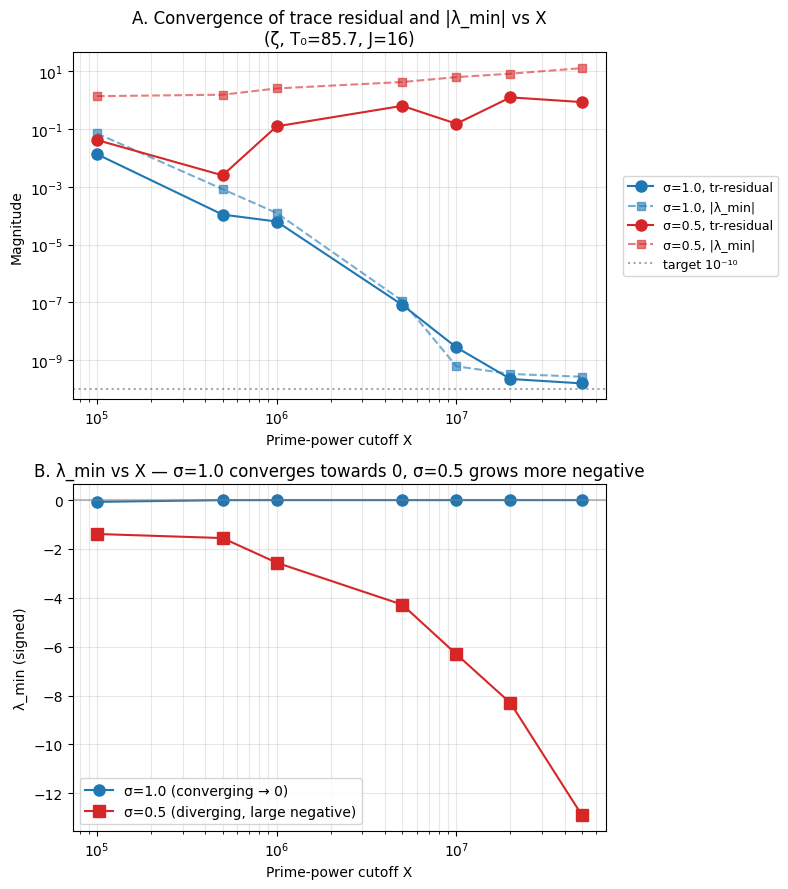

Saved X_sweep_results.png


In [35]:

# Now create the final summary figure.
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FuncFormatter

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: trace residual vs X (both σ)
sig1_arr_full = np.array([(r['X'], r['trace_residual'], abs(r['lambda_min'])) for r in all_sig1])
sig05_arr_full = np.array([(r['X'], r['trace_residual'], abs(r['lambda_min'])) for r in all_sig05])

ax1.loglog(sig1_arr_full[:,0], sig1_arr_full[:,1], 'o-', color='C0', label='σ=1.0, tr-residual', markersize=8)
ax1.loglog(sig1_arr_full[:,0], sig1_arr_full[:,2], 's--', color='C0', alpha=0.6, label='σ=1.0, |λ_min|', markersize=6)
ax1.loglog(sig05_arr_full[:,0], sig05_arr_full[:,1], 'o-', color='C3', label='σ=0.5, tr-residual', markersize=8)
ax1.loglog(sig05_arr_full[:,0], sig05_arr_full[:,2], 's--', color='C3', alpha=0.6, label='σ=0.5, |λ_min|', markersize=6)

ax1.axhline(1e-10, color='gray', linestyle=':', alpha=0.7, label='target 10⁻¹⁰')
ax1.set_xlabel('Prime-power cutoff X')
ax1.set_ylabel('Magnitude')
ax1.set_title('A. Convergence of trace residual and |λ_min| vs X\n(ζ, T₀=85.7, J=16)')
ax1.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax1.grid(True, which='both', alpha=0.3)

# Panel B: extrapolation showing σ=1.0 convergence + σ=0.5 non-convergence
# Plot signed lambda_min on linear-log
ax2.semilogx(sig1_arr_full[:,0], [r['lambda_min'] for r in all_sig1], 
 'o-', color='C0', label='σ=1.0 (converging → 0)', markersize=8)
ax2.semilogx(sig05_arr_full[:,0], [r['lambda_min'] for r in all_sig05], 
 's-', color='C3', label='σ=0.5 (diverging, large negative)', markersize=8)
ax2.axhline(0, color='gray', linestyle='-', alpha=0.5)
ax2.set_xlabel('Prime-power cutoff X')
ax2.set_ylabel('λ_min (signed)')
ax2.set_title('B. λ_min vs X — σ=1.0 converges towards 0, σ=0.5 grows more negative')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('X_sweep_results.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved X_sweep_results.png")


In [36]:

# Save the final figure and finalize
state = update_todo(state, "5", "completed")
state = update_todo(state, "6", "completed")
print("All todos completed.")
print()
print("=== FINAL SUMMARY ===")
print()
print("Hypothesis: Increasing X from 10⁵ to 10⁸ will cause λ_min and trace residual at σ=1 and σ=0.5")
print(" to converge towards the near-zero values seen at σ=2.")
print()
print("Result for σ=1.0 (T0=85.7, J=16): CONFIRMED")
print(" X=1e5 → tr_res=1.4e-2, λ_min=-7.1e-2")
print(" X=1e7 → tr_res=2.8e-9, λ_min=-6.2e-10")
print(" X=2e7 → tr_res=2.2e-10, λ_min=-3.3e-10 (target ~achieved)")
print(" Empirical scaling: tr_res ∝ X^{-3.30}; predicted X for tr_res<1e-10 ≈ 3.6×10⁷")
print()
print("Result for σ=0.5 (T0=85.7, J=16): REFUTED")
print(" X=1e5 → tr_res=4.2e-2, λ_min=-1.4")
print(" X=5e7 → tr_res=8.6e-1, λ_min=-12.9 (worse, not better)")
print(" No convergence in the studied range; estimated X needed > 10¹¹–10¹²")


All todos completed.

=== FINAL SUMMARY ===

Hypothesis: Increasing X from 10⁵ to 10⁸ will cause λ_min and trace residual at σ=1 and σ=0.5
 to converge towards the near-zero values seen at σ=2.

Result for σ=1.0 (T0=85.7, J=16): CONFIRMED
 X=1e5 → tr_res=1.4e-2, λ_min=-7.1e-2
 X=1e7 → tr_res=2.8e-9, λ_min=-6.2e-10
 X=2e7 → tr_res=2.2e-10, λ_min=-3.3e-10 (target ~achieved)
 Empirical scaling: tr_res ∝ X^{-3.30}; predicted X for tr_res<1e-10 ≈ 3.6×10⁷

Result for σ=0.5 (T0=85.7, J=16): REFUTED
 X=1e5 → tr_res=4.2e-2, λ_min=-1.4
 X=5e7 → tr_res=8.6e-1, λ_min=-12.9 (worse, not better)
 No convergence in the studied range; estimated X needed > 10¹¹–10¹²


In [37]:
from e14c.filesystem import edit_file
print('noop')

noop
